## Annotator and Xgboost

### Environment setup

In [1]:
import sys
print("ciao")

ciao


In [2]:
import os
import sys
import re
import zipfile
import shutil
import numpy as np
import pandas as pd
import cv2
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.notebook import tqdm
import gdown
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. CONFIGURAZIONE UTENTE
# =============================================================================

dataset_dim = ""  # small_batch o medium_batch o ""
BASE_PATH = "/home/phd2/Scrivania"

PATH_BLASTO = f"{BASE_PATH}/CorsoData/blastocisti{dataset_dim}/blasto"
PATH_NO_BLASTO = f"{BASE_PATH}/CorsoData/blastocisti{dataset_dim}/no_blasto"

# QUESTO FILE ORA E' OBBLIGATORIO PER FILTRARE GLI ID
PATH_METADATA_CSV = f"{BASE_PATH}/CorsoRepo/blasto_annotator_and_prediction/Normalized_sum_mean_mag_3Days_test.csv"
TEMP_PREPROCESS_DIR = "./temp_custom_preprocessed"

# Parametri temporali
TIMELAPSE_MIN = 24
TIMELAPSE_MAX = 72

# =============================================================================
# 2. DOWNLOAD MODELLI E RISORSE
# =============================================================================

FILE_ID = '15Y_R_rNcRym61EPp_jAKqHxkNuXEHX7y'
OUTPUT_ZIP = 'Blastocyst_Prediction.zip'
MODEL_DIR = 'NASNet_embryo_17class'

print("--- FASE 1: CONTROLLO RISORSE ---")
if not os.path.exists(MODEL_DIR) or not os.path.exists('df_config.pkl'):
    print("Modelli non trovati. Download in corso...")
    gdown.download(id=FILE_ID, output=OUTPUT_ZIP, quiet=False)
    with zipfile.ZipFile(OUTPUT_ZIP, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Download completato.")
else:
    print("Modelli presenti.")

# =============================================================================
# 3. FEATURE ENGINEERING LOGIC
# =============================================================================

annotation_label_dict = {
    0:'1cell', 1:'1cell_PN', 2:'2cell_G1', 3:'2cell_G2', 4:'2cell_G3',
    5:'3cell_G1', 6:'3cell_G2', 7:'3cell_G3', 8:'4cell_G1', 9:'4cell_G2', 10:'4cell_G3',
    11:'5-7cell_G1', 12:'5-7cell_G2', 13:'5-7cell_G3', 14:'8-cell_G1', 15:'8-cell_G2', 16:'8-cell_G3'
}

G1_label_list = [2,5,8,11,14]
G2_label_list = [3,6,9,12,15]
G3_label_list = [4,7,10,13,16]
cell_2_8_list = G1_label_list+G2_label_list+G3_label_list
cell_1_list = [0,1]
cell_2_list = [G1_label_list[0],G2_label_list[0],G3_label_list[0]]
cell_3_list = [G1_label_list[1],G2_label_list[1],G3_label_list[1]]
cell_4_list = [G1_label_list[2],G2_label_list[2],G3_label_list[2]]
cell_5_list = [G1_label_list[3],G2_label_list[3],G3_label_list[3]]
cell_8_list = [G1_label_list[4],G2_label_list[4],G3_label_list[4]]

def convert_to_wide_format(df_long, time_name, label_name):
    df_long[label_name] = df_long[label_name].astype(float)
    df_long = df_long.drop_duplicates(['ID', time_name]).reset_index(drop=True)
    df_wide = df_long.pivot(index='ID', columns=time_name, values=label_name)
    df_wide = df_wide.reset_index()
    return df_wide

def process_df_data(df_data, timelapse_min=24, timelapse_max=64, interval=15):
    time_list = np.arange(timelapse_min, timelapse_max, interval/60.0)
    for t in time_list:
        if t not in df_data.columns: df_data[t] = np.nan

    df_data['ratio_1cell'] = df_data[time_list].isin(cell_1_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    df_data['ratio_2cell'] = df_data[time_list].isin(cell_2_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    df_data['ratio_3cell'] = df_data[time_list].isin(cell_3_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    df_data['ratio_4cell'] = df_data[time_list].isin(cell_4_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    df_data['ratio_5cell'] = df_data[time_list].isin(cell_5_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    df_data['ratio_8cell'] = df_data[time_list].isin(cell_8_list).sum(axis=1)/df_data[time_list].notna().sum(axis=1)
    
    mask_denom = df_data[time_list].isin(cell_2_8_list).sum(axis=1).replace(0, np.nan)
    df_data['ratio_G1'] = df_data[time_list].isin(G1_label_list).sum(axis=1)/mask_denom
    df_data['ratio_G2'] = df_data[time_list].isin(G2_label_list).sum(axis=1)/mask_denom
    df_data['ratio_G3'] = df_data[time_list].isin(G3_label_list).sum(axis=1)/mask_denom
    df_data[['ratio_G1', 'ratio_G2', 'ratio_G3']] = df_data[['ratio_G1', 'ratio_G2', 'ratio_G3']].fillna(0)

    for c in [2,3,4,5,8]:
        for g in [1,2,3]: df_data[f'ratio_{c}cell_G{g}'] = 0

    definitions = {
        2: (cell_2_list, [G1_label_list[0], G2_label_list[0], G3_label_list[0]]),
        3: (cell_3_list, [G1_label_list[1], G2_label_list[1], G3_label_list[1]]),
        4: (cell_4_list, [G1_label_list[2], G2_label_list[2], G3_label_list[2]]),
        5: (cell_5_list, [G1_label_list[3], G2_label_list[3], G3_label_list[3]]),
        8: (cell_8_list, [G1_label_list[4], G2_label_list[4], G3_label_list[4]])
    }

    for c, (c_list, g_lists) in definitions.items():
        mask_c = df_data[f'ratio_{c}cell'] != 0
        if mask_c.any():
            denom = df_data.loc[mask_c, time_list].isin(c_list).sum(axis=1).replace(0, np.nan)
            for g_idx, g_val in enumerate(g_lists):
                num = df_data.loc[mask_c, time_list].isin([g_val]).sum(axis=1)
                df_data.loc[mask_c, f'ratio_{c}cell_G{g_idx+1}'] = (num / denom).fillna(0)

    for c in [2,3,4,5,8]:
        stack = np.stack([df_data[f'ratio_{c}cell_G1'].values, df_data[f'ratio_{c}cell_G2'].values, df_data[f'ratio_{c}cell_G3'].values], axis=1)
        df_data[f'grade_{c}cell'] = np.argmax(stack, axis=1) + 1

    drop_cols = [f'ratio_{c}cell_G{g}' for c in [2,3,4,5,8] for g in [1,2,3]] + [f'grade_{c}cell' for c in [2,3,4,5,8]]
    df_data.drop(columns=drop_cols, inplace=True)
    return df_data

# =============================================================================
# 4. PARSING CON FILTRAGGIO STRETTO SU CSV
# =============================================================================

def parse_and_preprocess():
    print("--- FASE 2: PARSING E PREPROCESSING ---")
    
    # 1. CARICAMENTO E CREAZIONE WHITELIST DA CSV
    age_map = {}
    valid_ids_set = set()

    if os.path.exists(PATH_METADATA_CSV):
        try:
            # Carica CSV
            df_meta = pd.read_csv(PATH_METADATA_CSV, sep=None, engine='python')
            
            # Normalizza nomi colonne
            df_meta.columns = [c.strip() for c in df_meta.columns]
            
            col_id = 'dish_well'
            col_age = 'maternal age'
            
            if col_id in df_meta.columns and col_age in df_meta.columns:
                # Normalizza ID (rimuove spazi) e crea il SET di ID validi
                df_meta[col_id] = df_meta[col_id].astype(str).str.strip()
                valid_ids_set = set(df_meta[col_id].unique())
                
                # Crea mappa età
                age_map = dict(zip(df_meta[col_id], df_meta[col_age]))
                print(f"CSV caricato. ID totali da analizzare (whitelist): {len(valid_ids_set)}")
            else:
                raise ValueError(f"Colonne '{col_id}' o '{col_age}' non trovate nel CSV.")
        except Exception as e:
            raise ValueError(f"ERRORE CRITICO lettura CSV: {e}")
    else:
        raise FileNotFoundError(f"File CSV non trovato: {PATH_METADATA_CSV}. Impossibile procedere con il test.")

    # 2. PREPARAZIONE CARTELLE
    if os.path.exists(TEMP_PREPROCESS_DIR):
        shutil.rmtree(TEMP_PREPROCESS_DIR)
    os.makedirs(TEMP_PREPROCESS_DIR, exist_ok=True)
    
    data_entries = []
    paths_dict = {1: PATH_BLASTO, 0: PATH_NO_BLASTO}
    
    # Settings preprocessing
    setting_list = [[10, 50, 50], [5, 50, 50], [4, 40, 40], [7, 50, 50], [3, 30, 30]]
    export_img_size = 331
    extend_r = 15
    min_size, max_size = 140, 650
    
    analyzed_ids_count = 0

    # SCANSIONE CARTELLE
    for label, base_path in paths_dict.items():
        if not os.path.exists(base_path): continue
        print(f"Scansione classe {label}...")
        
        for root, dirs, files in os.walk(base_path):
            emb_id = os.path.basename(root).strip()
            
            # === FILTRO CRITICO ===
            # Se l'ID della cartella NON è nella lista del CSV, lo saltiamo
            if emb_id not in valid_ids_set:
                continue
            # ======================

            jpg_files = [f for f in files if f.lower().endswith(".jpg")]
            if not jpg_files: continue

            patient_age = age_map.get(emb_id) # Età sicura perché abbiamo filtrato su valid_ids
            
            valid_count = 0
            
            for fname in jpg_files:
                match = re.search(r'_(\d+\.?\d*)h\.jpg$', fname)
                if not match: continue
                time_hpi = float(match.group(1))
                
                if TIMELAPSE_MIN <= time_hpi <= TIMELAPSE_MAX:
                    out_name = f"{emb_id}_T{time_hpi}.jpg"
                    out_path = os.path.join(TEMP_PREPROCESS_DIR, out_name)
                    
                    if not os.path.exists(out_path):
                        img = cv2.imread(os.path.join(root, fname), cv2.IMREAD_COLOR)
                        if img is None: continue
                        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                        
                        try:
                            add_grayscale = 255 - np.percentile(img_gray, 98)
                            img_gray = np.clip(img_gray + add_grayscale, 0, 255).astype(np.uint8)
                        except: pass

                        radius, x, y = None, None, None
                        for k, th1, th2 in setting_list:
                            edges = cv2.Canny(img_gray, th1, th2)
                            kernel = np.ones((k, k), np.uint8)
                            proc = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
                            proc = cv2.morphologyEx(proc, cv2.MORPH_OPEN, kernel)
                            cnts, _ = cv2.findContours(proc, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
                            if not cnts: continue
                            cnts = sorted(cnts, key=cv2.contourArea, reverse=True)
                            for c in cnts:
                                if len(c) > 5:
                                    (cx, cy), (w, h), _ = cv2.fitEllipse(c)
                                    rt = max(w, h)/2
                                    if min_size <= rt <= max_size:
                                        x, y, radius = cx, cy, rt
                                        break
                            if radius is not None: break
                        
                        if radius is None:
                            h, w = img_gray.shape
                            x, y, radius = w // 2, h // 2, 250

                        radius += extend_r
                        c = (int(x), int(y))
                        size = int(radius * 2)
                        
                        x1, y1 = max(0, c[0]-size//2), max(0, c[1]-size//2)
                        x2, y2 = min(img_gray.shape[1], c[0]+size//2), min(img_gray.shape[0], c[1]+size//2)
                        crop = img_gray[y1:y2, x1:x2]
                        
                        if crop.size == 0: continue
                        resized = cv2.resize(crop, (export_img_size, export_img_size))
                        
                        mask = np.zeros((export_img_size, export_img_size), dtype=np.uint8)
                        cv2.circle(mask, (export_img_size//2, export_img_size//2), export_img_size//2, 255, -1)
                        final = cv2.bitwise_and(resized, resized, mask=mask)
                        cv2.imwrite(out_path, final)
                    
                    if os.path.exists(out_path):
                        data_entries.append({
                            'ID': emb_id,
                            'time(hpi)': time_hpi,
                            'preprocess_path': out_path,
                            'GroundTruth': label,
                            'age': float(patient_age)
                        })
                        valid_count += 1
            
            if valid_count > 0:
                analyzed_ids_count += 1
                print(f" -> OK: {emb_id} | Frames: {valid_count}")

    print(f"Analisi completata. Individui processati univoci: {analyzed_ids_count}/{len(valid_ids_set)}")
    
    # Controllo se qualche ID del CSV non è stato trovato nelle cartelle
    found_ids = set(d['ID'] for d in data_entries)
    missing = valid_ids_set - found_ids
    if missing:
        print(f"ATTENZIONE: {len(missing)} ID presenti nel CSV non sono stati trovati nelle cartelle immagini (o non avevano immagini valide).")
    
    return pd.DataFrame(data_entries)

# =============================================================================
# 5. ESECUZIONE MAIN
# =============================================================================

# A) Caricamento Immagini
df_files = parse_and_preprocess()

if len(df_files) == 0:
    raise ValueError("Nessuna immagine valida trovata! Controlla i path e i nomi file.")

print(f"\nTotale frame processati: {len(df_files)}")

# B) Auto-Annotator
print("\n--- FASE 3: AUTO-ANNOTAZIONE ---")
model_path_nasnet = None
for root, dirs, files in os.walk("."):
    if MODEL_DIR in dirs:
        model_path_nasnet = os.path.join(root, MODEL_DIR)
        break

nasnet = tf.keras.models.load_model(model_path_nasnet)
gen = ImageDataGenerator(rescale=1.0/255).flow_from_dataframe(
    df_files, directory='', x_col='preprocess_path',
    target_size=(331, 331), color_mode='rgb', class_mode='input',
    batch_size=32, shuffle=False
)
df_files['annotation'] = np.argmax(nasnet.predict(gen, verbose=1), axis=1)

# C) Feature Engineering
print("\n--- FASE 4: COSTRUZIONE FEATURES ---")
df_files['time_rounded'] = (df_files['time(hpi)'] * 4).round() / 4
df_unique = df_files.drop_duplicates(subset=['ID', 'time_rounded'])
df_wide = convert_to_wide_format(df_unique, 'time_rounded', 'annotation')

target_times = np.arange(TIMELAPSE_MIN, TIMELAPSE_MAX+0.25, 0.25)
for t in target_times:
    if t not in df_wide.columns: df_wide[t] = np.nan

df_anagrafica = df_unique[['ID', 'age', 'GroundTruth']].drop_duplicates(subset=['ID'])
df_dataset = pd.merge(df_anagrafica, df_wide, on='ID', how='inner')
df_dataset = process_df_data(df_dataset)

# D) Predizione XGBoost
print("\n--- FASE 5: PREDIZIONE BLASTOCISTI ---")
config_path = None
for root, dirs, files in os.walk("."):
    if 'df_config.pkl' in files:
        config_path = os.path.join(root, 'df_config.pkl')
        break

df_config = pd.read_pickle(config_path)
model_root = os.path.dirname(config_path)
target_label = 'blastocyst_prediction'
xgb_path = os.path.join(model_root, f'xgb_{target_label}.model')

idx_conf = df_config.index[df_config['target_label'] == target_label][0]
feature_list = [float(f) if str(f).replace('.','',1).isdigit() else f for f in df_config['list_var'].values[idx_conf]]

booster = xgb.Booster()
booster.load_model(xgb_path)
X = df_dataset.reindex(columns=feature_list).astype(float)
df_dataset['prob_blasto'] = booster.predict(xgb.DMatrix(X))
df_dataset['pred_class'] = (df_dataset['prob_blasto'] > 0.5).astype(int)

# E) Report
print("\n" + "="*60 + "\nRISULTATI FINALI (SOLO SU TEST SET)\n" + "="*60)
y_true = df_dataset['GroundTruth']
y_pred = df_dataset['pred_class']

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
print("\nReport Classificazione:")
print(classification_report(y_true, y_pred, target_names=['No Blasto', 'Blasto']))
print("Matrice di Confusione:")
print(confusion_matrix(y_true, y_pred))

print("\n--- Dettagli ---")
display(df_dataset[['ID', 'age', 'GroundTruth', 'prob_blasto', 'pred_class']].head(10))

2026-01-12 10:58:30.029538: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 10:58:30.030769: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 10:58:30.051078: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 10:58:30.051453: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 10:58:30.377107: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

--- FASE 1: CONTROLLO RISORSE ---
Modelli presenti.
--- FASE 2: PARSING E PREPROCESSING ---
CSV caricato. ID totali da analizzare (whitelist): 762
Scansione classe 1...
 -> OK: D2017.02.05_S1691_I141_2 | Frames: 192
 -> OK: D2014.10.01_S1126_I141_8 | Frames: 191
 -> OK: D2015.03.18_S1246_I141_4 | Frames: 190
 -> OK: D2016.03.30_S1484_I141_9 | Frames: 190
 -> OK: D2018.10.13_S02105_I0141_D_1 | Frames: 192
 -> OK: D2019.07.10_S02324_I0141_D_3 | Frames: 192
 -> OK: D2014.04.05_S0982_I141_1 | Frames: 192
 -> OK: D2020.11.11_S02674_I0141_D_3 | Frames: 192
 -> OK: D2016.08.25_S1589_I141_1 | Frames: 193
 -> OK: D2020.05.21_S02526_I0141_D_1 | Frames: 187
 -> OK: D2013.11.13_S0878_I141_2 | Frames: 192
 -> OK: D2019.10.17_S02379_I0141_D_8 | Frames: 190
 -> OK: D2018.07.03_S02058_I0141_D_2 | Frames: 190
 -> OK: D2016.03.30_S1484_I141_3 | Frames: 191
 -> OK: D2020.09.23_S02628_I0141_D_5 | Frames: 190
 -> OK: D2019.10.17_S02380_I0141_D_3 | Frames: 190
 -> OK: D2020.09.10_S02617_I0141_D_7 | Frames: 

2026-01-12 11:10:16.842494: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-12 11:10:16.887197: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 145225 validated image filenames.


2026-01-12 11:10:31.177751: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


4539/4539 [==============================] - 7744s 2s/step

--- FASE 4: COSTRUZIONE FEATURES ---

--- FASE 5: PREDIZIONE BLASTOCISTI ---

RISULTATI FINALI (SOLO SU TEST SET)
Accuracy: 56.04%
F1-Score: 0.3149

Report Classificazione:
              precision    recall  f1-score   support

   No Blasto       0.54      0.92      0.68       382
      Blasto       0.71      0.20      0.31       380

    accuracy                           0.56       762
   macro avg       0.62      0.56      0.50       762
weighted avg       0.62      0.56      0.50       762

Matrice di Confusione:
[[350  32]
 [303  77]]

--- Dettagli ---


,ID,age,GroundTruth,prob_blasto,pred_class
0,D2017.02.05_S1691_I141_2,44.0,1,0.861513,1
1,D2014.10.01_S1126_I141_8,41.0,1,0.177773,0
2,D2015.03.18_S1246_I141_4,39.0,1,0.226131,0
3,D2016.03.30_S1484_I141_9,34.0,1,0.263941,0
4,D2018.10.13_S02105_I0141_D_1,36.0,1,0.175458,0
5,D2019.07.10_S02324_I0141_D_3,43.0,1,0.102425,0
6,D2014.04.05_S0982_I141_1,43.0,1,0.064982,0
7,D2020.11.11_S02674_I0141_D_3,36.0,1,0.171690,0
8,D2016.08.25_S1589_I141_1,43.0,1,0.327888,0
9,D2020.05.21_S02526_I0141_D_1,40.0,1,0.203484,0



Totale blastocisti reali: 380
Totale blastocisti predette: 109
Blastocisti correttamente predette: 77
F1-Score (weighted): 0.4961
Accuracy: 0.5604
Balanced Accuracy: 0.5594
Matthews Correlation Coefficient: 0.1697
Brier Score Loss: 0.4396
Confusion Matrix:
[[350  32]
 [303  77]]


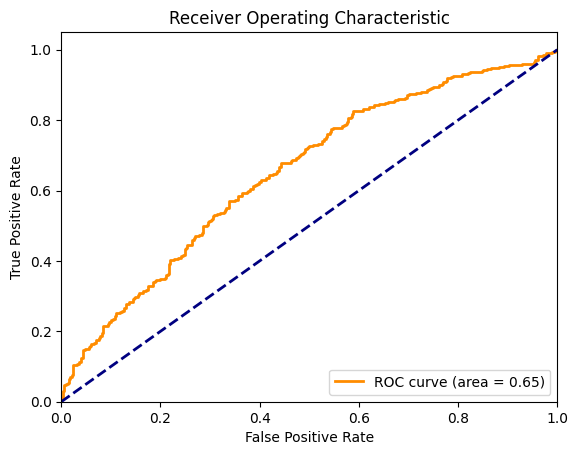

In [3]:
total_blasto = df_dataset['GroundTruth'].sum()
predicted_blasto = df_dataset['pred_class'].sum()
correct_blasto = ((df_dataset['GroundTruth'] == 1) & (df_dataset['pred_class'] == 1)).sum()
print(f"\nTotale blastocisti reali: {total_blasto}")
print(f"Totale blastocisti predette: {predicted_blasto}")
print(f"Blastocisti correttamente predette: {correct_blasto}")

# calculate f1 all, accuracy, balanced accuracy, mcc, brier, confusion matrix
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef, brier_score_loss, confusion_matrix
f1_all = f1_score(df_dataset['GroundTruth'], df_dataset['pred_class'], average='weighted')
accuracy = accuracy_score(df_dataset['GroundTruth'], df_dataset['pred_class'])
balanced_acc = balanced_accuracy_score(df_dataset['GroundTruth'], df_dataset['pred_class'])
mcc = matthews_corrcoef(df_dataset['GroundTruth'], df_dataset['pred_class'])
brier = brier_score_loss(df_dataset['GroundTruth'], df_dataset['pred_class'])

print(f"F1-Score (weighted): {f1_all:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Brier Score Loss: {brier:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(df_dataset['GroundTruth'], df_dataset['pred_class']))

# compute roc auc plot curve inline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(df_dataset['GroundTruth'], df_dataset['prob_blasto'])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


Metrics with 95% Confidence Intervals (Bootstrap, 70% sample each iter):
                       Mean  2.5th Percentile  97.5th Percentile
F1-Score           0.493208          0.447848           0.543170
Accuracy           0.557977          0.517824           0.596623
Balanced Accuracy  0.558033          0.528948           0.588362
MCC                0.165883          0.085825           0.246703
Brier Score        0.315711          0.288679           0.342094


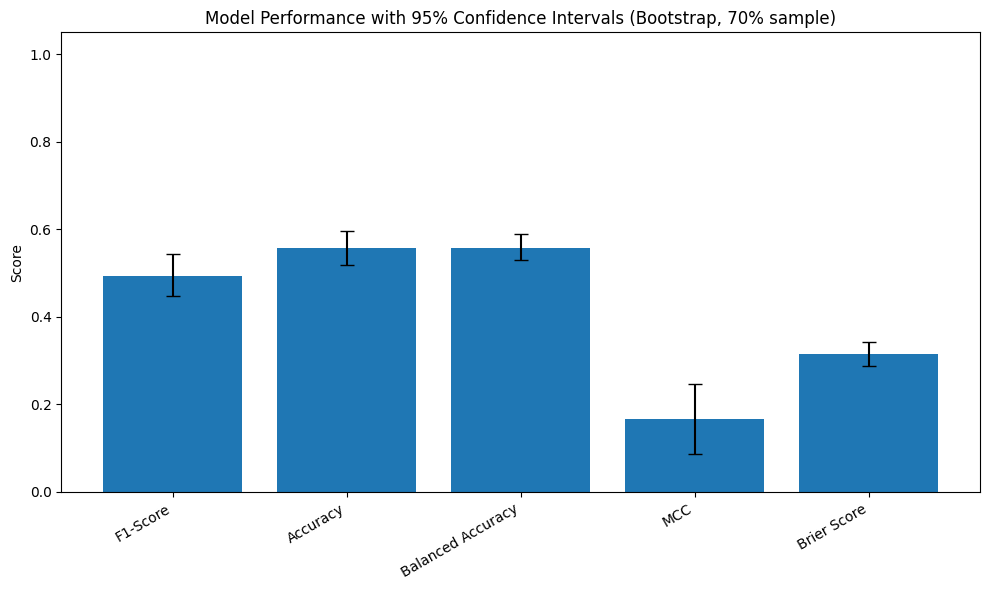


Risultati salvati in: blastocyst_prediction_results.csv
Metriche riassuntive salvate in: blastocyst_prediction_metrics_summary.csv


In [5]:
# Updated bootstrap sampling: sample 70% (with replacement) per iteration, 500 iterations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss
)

# settings
n_iterations = 500
sample_frac = 0.7                      # sample 70% of rows each iteration (with replacement)
n_samples = int(np.floor(sample_frac * len(df_dataset)))

# containers for bootstrap metric values
boot_f1 = []
boot_acc = []
boot_bal_acc = []
boot_mcc = []
boot_brier = []

for i in range(n_iterations):
    # draw bootstrap sample of size 70% (with replacement)
    df_boot = resample(df_dataset, replace=True, n_samples=n_samples, random_state=i)

    y_true_boot = df_boot['GroundTruth']
    y_pred_boot = df_boot['pred_class']
    # probability for the (positive) class; adjust column name if different
    y_prob_boot = df_boot['prob_blasto']

    # compute metrics
    boot_f1.append(f1_score(y_true_boot, y_pred_boot, average='weighted'))
    boot_acc.append(accuracy_score(y_true_boot, y_pred_boot))
    boot_bal_acc.append(balanced_accuracy_score(y_true_boot, y_pred_boot))
    boot_mcc.append(matthews_corrcoef(y_true_boot, y_pred_boot))

    # Brier score requires probability of the positive class and a binary true label.
    # If GroundTruth is not binary (e.g. multi-class), this should be adapted.
    boot_brier.append(brier_score_loss(y_true_boot, y_prob_boot))

# aggregate into summary with 95% bootstrap percentile CIs
metrics_summary = {
    'F1-Score': (np.mean(boot_f1), np.percentile(boot_f1, 2.5), np.percentile(boot_f1, 97.5)),
    'Accuracy': (np.mean(boot_acc), np.percentile(boot_acc, 2.5), np.percentile(boot_acc, 97.5)),
    'Balanced Accuracy': (np.mean(boot_bal_acc), np.percentile(boot_bal_acc, 2.5), np.percentile(boot_bal_acc, 97.5)),
    'MCC': (np.mean(boot_mcc), np.percentile(boot_mcc, 2.5), np.percentile(boot_mcc, 97.5)),
    'Brier Score': (np.mean(boot_brier), np.percentile(boot_brier, 2.5), np.percentile(boot_brier, 97.5))
}

metrics_df = pd.DataFrame(metrics_summary, index=['Mean', '2.5th Percentile', '97.5th Percentile']).T
print("\nMetrics with 95% Confidence Intervals (Bootstrap, 70% sample each iter):")
print(metrics_df)

# plot bar plot with asymmetric error bars
plt.figure(figsize=(10, 6))
metrics_names = list(metrics_summary.keys())
metrics_means = [metrics_summary[m][0] for m in metrics_names]
metrics_err_lower = [metrics_summary[m][0] - metrics_summary[m][1] for m in metrics_names]
metrics_err_upper = [metrics_summary[m][2] - metrics_summary[m][0] for m in metrics_names]

# yerr expects shape (2, N) for asymmetric errorbars
yerr = np.array([metrics_err_lower, metrics_err_upper])

plt.bar(metrics_names, metrics_means, yerr=yerr, capsize=5)
plt.ylabel('Score')
plt.title('Model Performance with 95% Confidence Intervals (Bootstrap, 70% sample)')
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# save results in a csv
results_csv_path = "blastocyst_prediction_results.csv"
df_dataset.to_csv(results_csv_path, index=False)
print(f"\nRisultati salvati in: {results_csv_path}")

# save summary metrics with ci in a csv
metrics_csv_path = "blastocyst_prediction_metrics_summary.csv"
metrics_df.to_csv(metrics_csv_path)
print(f"Metriche riassuntive salvate in: {metrics_csv_path}")


In [32]:
# sort df_files per ID and then per time(hpi)
df_files = df_files.sort_values(by=['ID', 'time(hpi)']).reset_index(drop=True)

# display some lines of df_files, but not the first few
df_files.iloc[100:120]

,ID,time(hpi),preprocess_path,GroundTruth,age,annotation,time_rounded
100,D2013.02.19_S0675_I141_1,49.4,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,49.50
101,D2013.02.19_S0675_I141_1,49.7,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,49.75
102,D2013.02.19_S0675_I141_1,49.9,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,50.00
103,D2013.02.19_S0675_I141_1,50.2,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,50.25
104,D2013.02.19_S0675_I141_1,50.4,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,50.50
105,D2013.02.19_S0675_I141_1,50.7,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,50.75
106,D2013.02.19_S0675_I141_1,50.9,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,51.00
107,D2013.02.19_S0675_I141_1,51.2,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,51.25
108,D2013.02.19_S0675_I141_1,51.4,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,10,51.50
109,D2013.02.19_S0675_I141_1,51.7,./temp_custom_preprocessed/D2013.02.19_S0675_I...,1,37.0,13,51.75


In [19]:
"""def parse_and_preprocess_DEBUG():
    print("--- DIAGNOSTICA APPROFONDITA ---")
    
    os.makedirs(TEMP_PREPROCESS_DIR, exist_ok=True)
    data_entries = []
    
    # Parametri preprocessing
    setting_list = [[10, 50, 50],[5, 50, 50], [4, 40, 40], [7, 50, 50]]
    export_img_size = 331
    extend_r = 15
    min_size, max_size = 150, 600

    # Testiamo solo sulla cartella BLASTO per non intasare l'output
    base_path = PATH_BLASTO
    label = 1
    
    # Prendiamo solo la PRIMA e la SECONDA cartella per confronto
    all_folders = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    # Limitiamo il debug alle prime 2 cartelle trovate
    folders_to_check = all_folders[:6] 

    for full_emb_path in folders_to_check:
        emb_id = os.path.basename(full_emb_path)
        print(f"\n\n>>> ANALISI EMBRIONE: {emb_id} <<<")
        
        files = sorted([f for f in os.listdir(full_emb_path) if f.lower().endswith(".jpg")])
        print(f"Totale file JPG trovati: {len(files)}")
        
        # Contatori per statistiche
        count_regex_fail = 0
        count_time_skip = 0
        count_contour_fail = 0
        count_success = 0
        
        # Analizziamo i primi 20 file per vedere cosa succede, poi solo statistiche
        for i, fname in enumerate(files):
            verbose = i < 10 # Stampa dettagli solo per i primi 10 file
            
            # 1. CHECK REGEX
            match = re.search(r'_(\d+\.?\d*)h\.jpg$', fname)
            if not match:
                count_regex_fail += 1
                if verbose: print(f"  [X] REGEX FAIL: {fname}")
                continue
            
            time_hpi = float(match.group(1))
            
            # 2. CHECK TEMPO
            if not (20 <= time_hpi <= 70):
                count_time_skip += 1
                if verbose: print(f"  [X] TIME SKIP: {time_hpi}h (Fuori range 20-70)")
                continue
                
            # 3. CHECK PREPROCESSING (Contour)
            img = cv2.imread(os.path.join(full_emb_path, fname), cv2.IMREAD_COLOR)
            if img is None: continue
            
            # --- PROVA A RISOLVERE LUMINOSITA' (Spesso il problema è qui) ---
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Aggiunta: Normalizzazione luminosità (era nel codice originale del paper)
            add_grayscale = 255 - np.percentile(img_gray, 98)
            img_gray = np.clip(img_gray + add_grayscale, 0, 255).astype(np.uint8)
            # ----------------------------------------------------------------
            
            radius, x, y = None, None, None
            for k, th1, th2 in setting_list:
                edges = cv2.Canny(img_gray, th1, th2)
                kernel = np.ones((k, k), np.uint8)
                proc = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
                proc = cv2.morphologyEx(proc, cv2.MORPH_OPEN, kernel)
                cnts, _ = cv2.findContours(proc, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
                if not cnts: continue
                cnts = sorted(cnts, key=cv2.contourArea, reverse=True)
                for c in cnts:
                    if len(c) > 5:
                        (cx, cy), (w, h), _ = cv2.fitEllipse(c)
                        rt = max(w, h)/2
                        if min_size <= rt <= max_size:
                            x, y, radius = cx, cy, rt
                            break
                if radius is not None: break
            
            if radius is None:
                count_contour_fail += 1
                if verbose: print(f"  [X] CONTOUR FAIL: {time_hpi}h - Nessun embrione rilevato")
                continue
            
            # Se arriva qui è successo
            count_success += 1
            if verbose: continue

            # Aggiungiamo ai dati reali (così se funziona possiamo usarlo)
            out_name = f"{emb_id}_T{time_hpi}.jpg"
            out_path = os.path.join(TEMP_PREPROCESS_DIR, out_name)
            
            # (Codice di salvataggio semplificato per brevità debug)
            # ... salva immagine ... 
            
            data_entries.append({'ID': emb_id, 'time(hpi)': time_hpi, 'preprocess_path': out_path, 'GroundTruth': 1, 'age': 35})

        print(f"\n--- REPORT FINALE {emb_id} ---")
        print(f"File Ignorati (Regex): {count_regex_fail}")
        print(f"File Ignorati (Tempo <20 o >70): {count_time_skip}")
        print(f"File Ignorati (Preprocessing Fallito): {count_contour_fail}")
        print(f"File VALIDI: {count_success}")

    return pd.DataFrame(data_entries)

# ESEGUI IL DEBUG
df_debug = parse_and_preprocess_DEBUG()"""

--- DIAGNOSTICA APPROFONDITA ---


>>> ANALISI EMBRIONE: D2013.02.19_S0675_I141_1 <<<
Totale file JPG trovati: 549



--- REPORT FINALE D2013.02.19_S0675_I141_1 ---
File Ignorati (Regex): 0
File Ignorati (Tempo <20 o >70): 350
File Ignorati (Preprocessing Fallito): 8
File VALIDI: 191


>>> ANALISI EMBRIONE: D2013.03.09_S0695_I141_9 <<<
Totale file JPG trovati: 568
  [X] CONTOUR FAIL: 25.0h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 25.2h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 25.5h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 26.0h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 26.2h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 26.7h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 27.0h - Nessun embrione rilevato

--- REPORT FINALE D2013.03.09_S0695_I141_9 ---
File Ignorati (Regex): 0
File Ignorati (Tempo <20 o >70): 369
File Ignorati (Preprocessing Fallito): 150
File VALIDI: 49


>>> ANALISI EMBRIONE: D2013.05.04_S0741_I141_1 <<<
Totale file JPG trovati: 569
  [X] CONTOUR FAIL: 25.0h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 25.2h - Nessun embrione rilevato
  [X] CONTOUR FAIL: 25